/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


-0.0015077491806469907


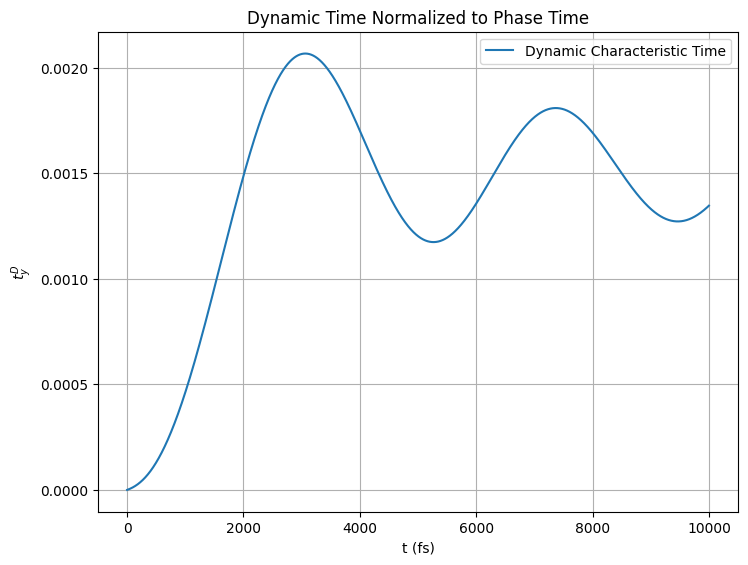

In [1]:
import sympy as sp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special
import os
import math

def moshinsky_function(x, k, t, m, hbar):
    M = (1/2) * special.erfc((x - (hbar * k * t / m)) / (np.sqrt(2 * hbar * 1j * t / m))) * np.exp(1j * (k * x - hbar * (k**2) * t / (2 * m)))
    return M

hbar = 6.582119e-1
V0 = 0.1
a = 50
c = 3e8
x = 700
E0 = 0.001
m = 0.067 * 1e10 * 0.510998e6 / c**2
m_e = 0.067 * 5.6791e-8
K0 = np.sqrt((2 * m * E0) / (hbar**2))
Kv0 = np.sqrt((2 * m * V0) / (hbar**2))
Alpha = a * Kv0
Gamma = math.tanh(Alpha) * (Kv0 / 2)
Tk = (K0**2) / (math.cosh(Alpha)**2 * (K0**2 + Gamma**2))

t = np.linspace(0.01, 10000, 1000000)
tD_y = ((moshinsky_function(x - a, K0, t, m, hbar) * np.conj(moshinsky_function(x - a, K0, t, m, hbar))) * (m / (hbar * Kv0)) * (2 * a * K0 * ((a * Kv0) * (1 / np.cosh(a * Kv0))**2 + np.tanh(a * Kv0)) / (4 * a**2 * K0 + Kv0**2 * (np.tanh(a * Kv0)**2))))
t_phase = -1 * ((m / (hbar * Kv0)) * (2 * a * K0 * ((a * Kv0) * (1 / np.cosh(a * Kv0))**2 + np.tanh(a * Kv0)) / (4 * a**2 * K0 + Kv0**2 * (np.tanh(a * Kv0)**2))))
magnitude_t_phase = np.abs(t_phase) + 0 * t

fig = plt.figure(2)
ax = fig.add_axes([0, 0, 1, 1])
plt.grid()
line1, = plt.plot(t, tD_y, label='Dynamic Characteristic Time')
plt.legend(handles=[line1], loc='upper right')
ax.set_title("Dynamic Time Normalized to Phase Time")
ax.set_xlabel("t (fs)")
ax.set_ylabel("$t^D_y$")
plt.savefig("figure1000.png")
print(t_phase)